In [1]:
import os
import sys
import random

# Přidání cesty pro vlastní moduly
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

# Nastavení deterministického chování pro CuBLAS
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import torch.nn.functional as F
import torch.optim as optim

import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
from qsprpred.data.descriptors.sets import RDKitDescs

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

from MolEval import MolEmb


/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
# Přejmenování názvů sloupců
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)
# Doplnění NaNů pomocí průměrných hodnot v trénovací množině 
imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)

# Škálování dat
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
# Počet sloupců, který zachová 95% rozptylu
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

n_components = np.argmax(cum_var >= 0.95) + 1
display(n_components)

851

In [5]:
# Aplikování PCA na datasety
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

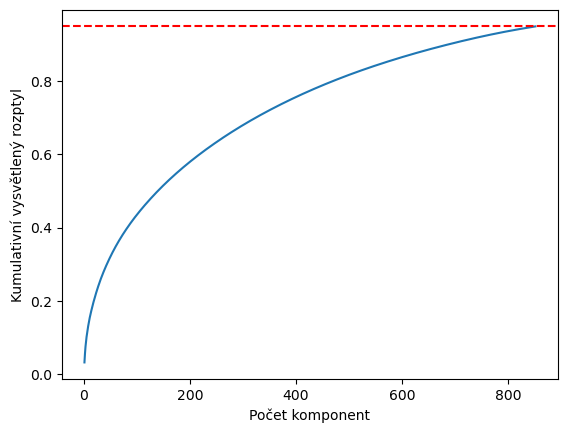

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [7]:
# Import vlastní neuronové sítě
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

from importlib import reload
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

/home/ubuntu/Bakalarka/QSPRpred
lol


In [8]:
def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    seed = 69  
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }
    # neuron_layers a optimizer řešen přes slovník, kvůli ukládání do MySQL databáze.
    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'], 
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'], 
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
        seed=seed,
        print_outputs = 2
    )
    
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metriky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [9]:
sampler = optuna.samplers.TPESampler(seed=69)
study = optuna.create_study(
    study_name="A2AR_nn_without_smote_7",  
    direction="maximize",
    sampler=sampler,
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  
)


study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=3
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-21 14:15:45,593] A new study created in RDB with name: A2AR_nn_without_smote_7


69
Epoch 1 | Train Loss: 21395.5742 | Valid Loss: 562486.1875 | MCC: 0.0240
Epoch 2 | Train Loss: 5855462.5000 | Valid Loss: 928183.6875 | MCC: -0.0075
Epoch 3 | Train Loss: 4263381.0000 | Valid Loss: 17622448.0000 | MCC: 0.1076
Epoch 4 | Train Loss: 11022502.0000 | Valid Loss: 15172878.0000 | MCC: -0.1727
Epoch 5 | Train Loss: 9614518.0000 | Valid Loss: 33104336.0000 | MCC: 0.0666
Epoch 6 | Train Loss: 2324614.5000 | Valid Loss: 28447848.0000 | MCC: 0.1160
Epoch 7 | Train Loss: 3257955.7500 | Valid Loss: 56315472.0000 | MCC: 0.0959
Epoch 8 | Train Loss: 1076510.6250 | Valid Loss: 68376744.0000 | MCC: 0.0801
Epoch 9 | Train Loss: 1216350.8750 | Valid Loss: 82005240.0000 | MCC: 0.0757
Epoch 10 | Train Loss: 2313282.0000 | Valid Loss: 165757344.0000 | MCC: 0.1153
Epoch 11 | Train Loss: 8791367.0000 | Valid Loss: 136240912.0000 | MCC: 0.0801
Epoch 12 | Train Loss: 3229548.2500 | Valid Loss: 103811424.0000 | MCC: 0.0711
Epoch 13 | Train Loss: 3735506.2500 | Valid Loss: 116121000.0000 | MCC

array([[ 30,   0],
       [781,   0]])

[I 2025-05-21 14:16:22,587] Trial 0 finished with value: 0.0 and parameters: {'dropout_frac': 0.2666242455051902, 'patience': 164, 'tol': 0.0001123977391667966, 'weight_decay': 0.008852099403875225, 'n_epochs': 1210, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 0.01, 'neuron_layers_size': '[4000, 2000, 1000, 500]'}. Best is trial 0 with value: 0.0.


69
Epoch 1 | Train Loss: 0.0537 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 2 | Train Loss: 0.0575 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 3 | Train Loss: 0.0471 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 4 | Train Loss: 0.0462 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 5 | Train Loss: 0.0634 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 6 | Train Loss: 0.0563 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 7 | Train Loss: 0.0673 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 8 | Train Loss: 0.0437 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 9 | Train Loss: 0.0581 | Valid Loss: 0.0514 | MCC: 0.0000
Epoch 10 | Train Loss: 0.0570 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 11 | Train Loss: 0.0533 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 12 | Train Loss: 0.0587 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 13 | Train Loss: 0.0654 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 14 | Train Loss: 0.0513 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 15 | Train Loss: 0.0479 | Valid Loss: 0.0513 | MCC: 0.0000
Epoch 16 | Train Loss: 0.0583 |

...

[I 2025-05-21 14:16:50,107] Trial 1 finished with value: 0.16485552926167812 and parameters: {'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 1e-06, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 1 with value: 0.16485552926167812.


69
Epoch 1 | Train Loss: 1732.9673 | Valid Loss: 1283.4060 | MCC: 0.0000
Epoch 2 | Train Loss: 1978.8185 | Valid Loss: 5284.3936 | MCC: 0.0000
Epoch 3 | Train Loss: 2399.9854 | Valid Loss: 2555.2786 | MCC: 0.0300
Epoch 4 | Train Loss: 3849.2932 | Valid Loss: 3009.8770 | MCC: 0.0569
Epoch 5 | Train Loss: 13722.1836 | Valid Loss: 3931.4685 | MCC: -0.0397
Epoch 6 | Train Loss: 2095.9978 | Valid Loss: 3683.7928 | MCC: -0.0464
Epoch 7 | Train Loss: 15878.7227 | Valid Loss: 5818.4871 | MCC: -0.0260
Epoch 8 | Train Loss: 3110.9976 | Valid Loss: 7525.1694 | MCC: 0.1806
Epoch 9 | Train Loss: 3422.9224 | Valid Loss: 8590.5254 | MCC: 0.1761
Epoch 10 | Train Loss: 23069.3184 | Valid Loss: 8854.5448 | MCC: 0.2000
Epoch 11 | Train Loss: 1137.2074 | Valid Loss: 9952.8045 | MCC: 0.0814
Epoch 12 | Train Loss: 2392.0508 | Valid Loss: 7773.1259 | MCC: 0.1030
Epoch 13 | Train Loss: 1469.6630 | Valid Loss: 8691.4043 | MCC: 0.1606
Epoch 14 | Train Loss: 2383.1211 | Valid Loss: 9995.7865 | MCC: 0.0192
Epoch 

array([[  0,  30],
       [  0, 781]])

[I 2025-05-21 14:17:12,479] Trial 2 finished with value: 0.0 and parameters: {'dropout_frac': 0.8843511316687515, 'patience': 67, 'tol': 0.0020364638681560927, 'weight_decay': 3.6286919688820005e-05, 'n_epochs': 1961, 'batch_size': 128, 'optimizer': 'AdamW', 'lr': 0.1, 'neuron_layers_size': '[2000, 1000, 500]'}. Best is trial 1 with value: 0.16485552926167812.


Best MCC: 0.16485552926167812
Best parameters: {'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 1e-06, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}
Best F1: 0.8208955223880597
Best ACC: 0.7040690505548706


In [10]:
test = study.best_params
test["neuron_layers"] = eval(test["neuron_layers_size"])
test["optimizer"] = eval("optim."+test["optimizer"])
test.pop("neuron_layers_size")
print(test)
seed=69
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model = STFullyConnected(
        n_dim=X1.shape[1],
    device = "cuda",
        n_class=1,
    print_outputs= 2,
    seed=69,
    **test
    )

model.fit(X1,y1,X2,y2) 
#trial[1].params={'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': 'RMSprop', 'lr': 1e-06, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}

{'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 1e-06, 'neuron_layers': [2048, 1024, 512, 256, 128, 64, 32, 16, 8]}
69
Epoch 1 | Train Loss: 0.0509 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 2 | Train Loss: 0.0593 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 3 | Train Loss: 0.0468 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 4 | Train Loss: 0.0496 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 5 | Train Loss: 0.0592 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 6 | Train Loss: 0.0536 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 7 | Train Loss: 0.0618 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 8 | Train Loss: 0.0407 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 9 | Train Loss: 0.0574 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 10 | Train Loss: 0.0588 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 11 | Train Loss: 0.0472 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=851, out_features=2048, bias=True)
     (1): Linear(in_features=2048, out_features=1024, bias=True)
     (2): Linear(in_features=1024, out_features=512, bias=True)
     (3): Linear(in_features=512, out_features=256, bias=True)
     (4): Linear(in_features=256, out_features=128, bias=True)
     (5): Linear(in_features=128, out_features=64, bias=True)
     (6): Linear(in_features=64, out_features=32, bias=True)
     (7): Linear(in_features=32, out_features=16, bias=True)
     (8): Linear(in_features=16, out_features=8, bias=True)
     (9): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.6123925418762083, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 0)

In [11]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.0

In [12]:
model = STFullyConnected(
        n_dim=X1.shape[1],
    device = "cuda",
        n_class=1,
    print_outputs= 2,
    seed=69,
    **test
    )

model.fit(X1,y1,X2,y2)

69
Epoch 1 | Train Loss: 0.0509 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 2 | Train Loss: 0.0593 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 3 | Train Loss: 0.0468 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 4 | Train Loss: 0.0496 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 5 | Train Loss: 0.0592 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 6 | Train Loss: 0.0536 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 7 | Train Loss: 0.0618 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 8 | Train Loss: 0.0407 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 9 | Train Loss: 0.0574 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 10 | Train Loss: 0.0588 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 11 | Train Loss: 0.0472 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 12 | Train Loss: 0.0539 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 13 | Train Loss: 0.0577 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 14 | Train Loss: 0.0536 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 15 | Train Loss: 0.0473 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 16 | Train Loss: 0.0533 |

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=851, out_features=2048, bias=True)
     (1): Linear(in_features=2048, out_features=1024, bias=True)
     (2): Linear(in_features=1024, out_features=512, bias=True)
     (3): Linear(in_features=512, out_features=256, bias=True)
     (4): Linear(in_features=256, out_features=128, bias=True)
     (5): Linear(in_features=128, out_features=64, bias=True)
     (6): Linear(in_features=64, out_features=32, bias=True)
     (7): Linear(in_features=32, out_features=16, bias=True)
     (8): Linear(in_features=16, out_features=8, bias=True)
     (9): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.6123925418762083, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 0)

In [13]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.0

In [14]:
test2 = study.best_params
test2["neuron_layers"] = eval(test2["neuron_layers_size"])
test2["optimizer"] = eval("optim."+test2["optimizer"])
test2.pop("neuron_layers_size")
print(test)
seed=69
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model2 = STFullyConnected(
        n_dim=X1.shape[1],
    device = "cuda",
        n_class=1,
    print_outputs= 2,
    seed=69,
    **test2
    )

model2.fit(X1,y1,X2,y2) 

{'dropout_frac': 0.6123925418762083, 'patience': 84, 'tol': 2.2370134039688746e-05, 'weight_decay': 0.0034365971994730943, 'n_epochs': 944, 'batch_size': 1024, 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 1e-06, 'neuron_layers': [2048, 1024, 512, 256, 128, 64, 32, 16, 8]}
69
Epoch 1 | Train Loss: 0.0509 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 2 | Train Loss: 0.0593 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 3 | Train Loss: 0.0468 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 4 | Train Loss: 0.0496 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 5 | Train Loss: 0.0592 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 6 | Train Loss: 0.0536 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 7 | Train Loss: 0.0618 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 8 | Train Loss: 0.0407 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 9 | Train Loss: 0.0574 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 10 | Train Loss: 0.0588 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch 11 | Train Loss: 0.0472 | Valid Loss: 0.0518 | MCC: 0.0000
Epoch

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=851, out_features=2048, bias=True)
     (1): Linear(in_features=2048, out_features=1024, bias=True)
     (2): Linear(in_features=1024, out_features=512, bias=True)
     (3): Linear(in_features=512, out_features=256, bias=True)
     (4): Linear(in_features=256, out_features=128, bias=True)
     (5): Linear(in_features=128, out_features=64, bias=True)
     (6): Linear(in_features=64, out_features=32, bias=True)
     (7): Linear(in_features=32, out_features=16, bias=True)
     (8): Linear(in_features=16, out_features=8, bias=True)
     (9): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.6123925418762083, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 0)

In [15]:
preds2 = model2.predict(X2)
preds_bin2 = preds2 > 0.5

mcc2 = matthews_corrcoef(y2, preds_bin2)
display(mcc2)

0.0